<a href="https://colab.research.google.com/github/kkumarisfdc/Kiran-s_Portfolio/blob/main/Dharan_Biotecnika_Copy_of_Assignment2_Biotechnika.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1) Data Generation
from google.colab import drive

from sklearn.datasets import make_classification
import pandas as pd

# Generate a synthetic dataset
df = pd.read_csv("chennai_reservoir_rainfall.csv")
X = df.drop('mutation_status', axis = 1)
Y = df['mutation_status']

# Convert to pandas DataFrame for better readability
df_features = pd.DataFrame(X, columns=[f'feature_{i}' for i in range(X.shape [1] )])
df_target = pd.DataFrame(y, columns=['mutation_status'])

df = pd.concat([df_features, df_target], axis=1)

print("Dataset shape:", df.shape)
display(df.head())

FileNotFoundError: [Errno 2] No such file or directory: 'chennai_reservoir_rainfall.csv'

In [ ]:
# 2) Data Splitting

from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df.drop('mutation_status', axis=1)
y = df['mutation_status']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print("X_train shape:", X_train. shape)
print("X_test shape:", X_test. shape)
print("y_train shape:", y_train. shape)
print("y_test shape:", y_test. shape)


X_train shape: (700, 20)
X_test shape: (300, 20)
y_train shape: (700,)
y_test shape: (300,)


In [ ]:
# 3) Train a Random Forest Classifier

from sklearn. ensemble import RandomForestClassifier

# Initialize the Random Forest Classifier
# n_estimators: The number of trees in the forest.
# random_state: Controls the randomness of the bootstrapping of the samples and features.
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_classifier.fit(X_train, y_train)

print("Random Forest Classifier trained successfully!")

Random Forest Classifier trained successfully!


Accuracy: 0.9167
Precision: 0.9085
Recall: 0.9267
F1-Score: 0.9175

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.91      0.92       150
           1       0.91      0.93      0.92       150

    accuracy                           0.92       300
   macro avg       0.92      0.92      0.92       300
weighted avg       0.92      0.92      0.92       300



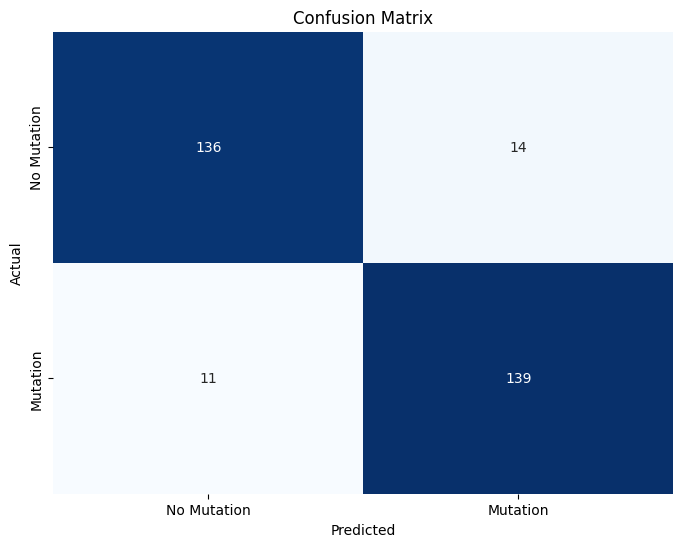

In [ ]:
# 4) Evaluate the Model

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions on the test set
y_pred = rf_classifier.predict(X_test)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy :. 4f}")
print(f"Precision: {precision :. 4f}")
print(f"Recall: {recall :. 4f}")
print(f"F1-Score: {f1 :. 4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Display Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns. heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
xticklabels=['No Mutation', 'Mutation'],
yticklabels=['No Mutation', 'Mutation'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt. show()


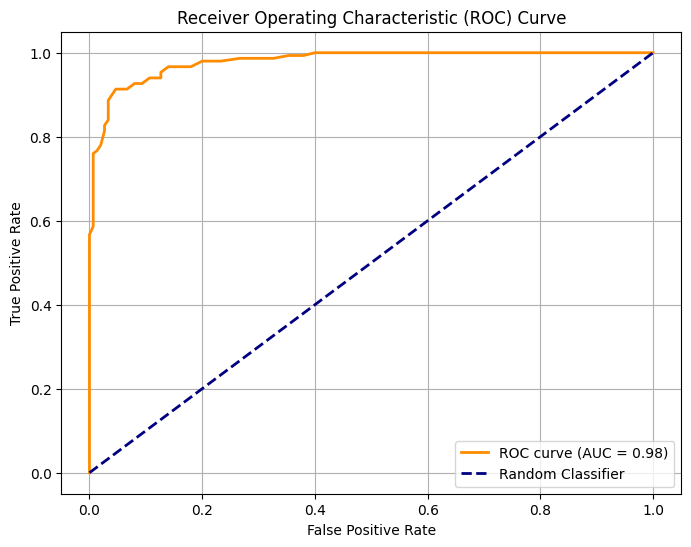

AUC Score:0.9795


In [ ]:
# 5) ROC Curve and AUC Score

from sklearn.metrics import roc_curve, roc_auc_score

# Get probabilities for the positive class (class 1 mutation)
y_pred_proba = rf_classifier.predict_proba(X_test)[:, 1]

# Calculate ROC curve values
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Calculate AUC score
auc_score = roc_auc_score(y_test, y_pred_proba)

# Plot the ROC curve

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print(f"AUC Score:{auc_score:.4f}")